# Previsão de Preços de Imóveis: Regressão Linear vs Random Forest

**Objetivo:** comparar um modelo linear simples com um modelo baseado em árvores na tarefa de prever o valor mediano de imóveis na Califórnia.

**Pergunta central:** vale a pena trocar a interpretabilidade da Regressão Linear pelo poder de modelar relações não lineares do Random Forest?

**Etapas:**
1. Carregamento e entendimento dos dados
2. Análise exploratória (EDA)
3. Separação entre treino e teste
4. Definição das métricas
5. Modelo de referência (baseline)
6. Regressão Linear
7. Random Forest Regressor
8. Validação cruzada
9. Comparação dos modelos
10. Conclusões e próximos passos

**Tecnologias:** Python, pandas, scikit-learn, matplotlib, seaborn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Semente fixa: garante que os resultados sejam reproduzíveis
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Carregando os dados

O dataset **California Housing** vem do censo americano de 1990. Cada linha representa um (uma pequena região), não uma casa individual.

| Coluna | Significado |
|---|---|
| `MedInc` | Renda mediana do bloco (em dezenas de milhares de dólares) |
| `HouseAge` | Idade mediana das casas |
| `AveRooms` | Média de cômodos por domicílio |
| `AveBedrms` | Média de quartos por domicílio |
| `Population` | População do bloco |
| `AveOccup` | Média de moradores por domicílio |
| `Latitude` | Latitude do bloco |
| `Longitude` | Longitude do bloco |
| `MedHouseVal` | **Alvo:** valor mediano das casas (em centenas de milhares de dólares) |

In [4]:
dados = fetch_california_housing(as_frame=True)
df = dados.frame

print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.head()

Linhas: 20640 | Colunas: 9


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# Tipos de dados e valores ausentes
print(df.dtypes)
print()
print("Valores ausentes por coluna:")
print(df.isna().sum())

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Valores ausentes por coluna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
HouseAge,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
AveRooms,20640.0,5.43,2.47,0.85,4.44,5.23,6.05,141.91
AveBedrms,20640.0,1.10,0.47,0.33,1.01,1.05,1.10,34.07
Population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
AveOccup,20640.0,3.07,10.39,0.69,2.43,2.82,3.28,1243.33
Latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
Longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
MedHouseVal,20640.0,2.07,1.15,0.15,1.20,1.80,2.65,5.00


## 2. Análise exploratória

Antes de treinar qualquer modelo, é preciso entender a distribuição do alvo e como as variáveis se relacionam com ele.

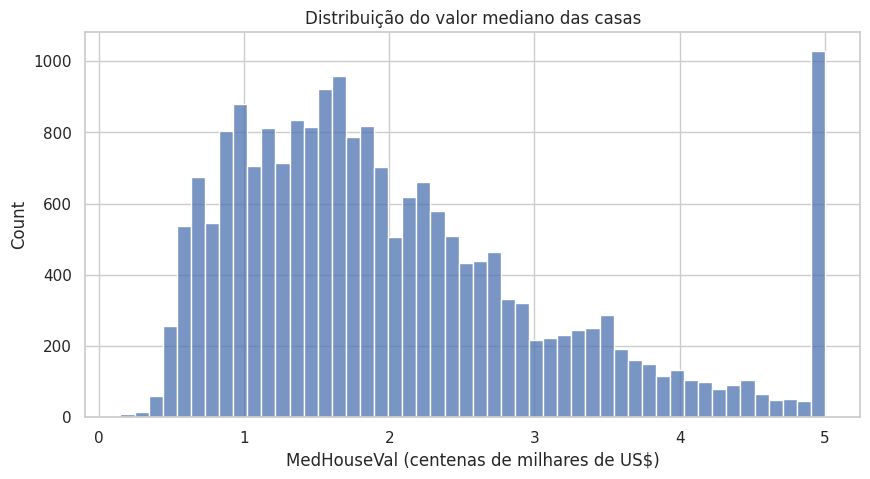

In [7]:
fig, ax = plt.subplots()
sns.histplot(df["MedHouseVal"], bins=50, ax=ax)
ax.set_title("Distribuição do valor mediano das casas")
ax.set_xlabel("MedHouseVal (centenas de milhares de US$)")
plt.show()

**Observação importante:** no dataset original, os valores foram limitados em 5.0 (US$ 500 mil). Isso aparece como um pico no final do histograma. Na prática, qualquer imóvel acima desse valor foi registrado como 5.0, então nenhum modelo consegue prever valores maiores que isso com esses dados.

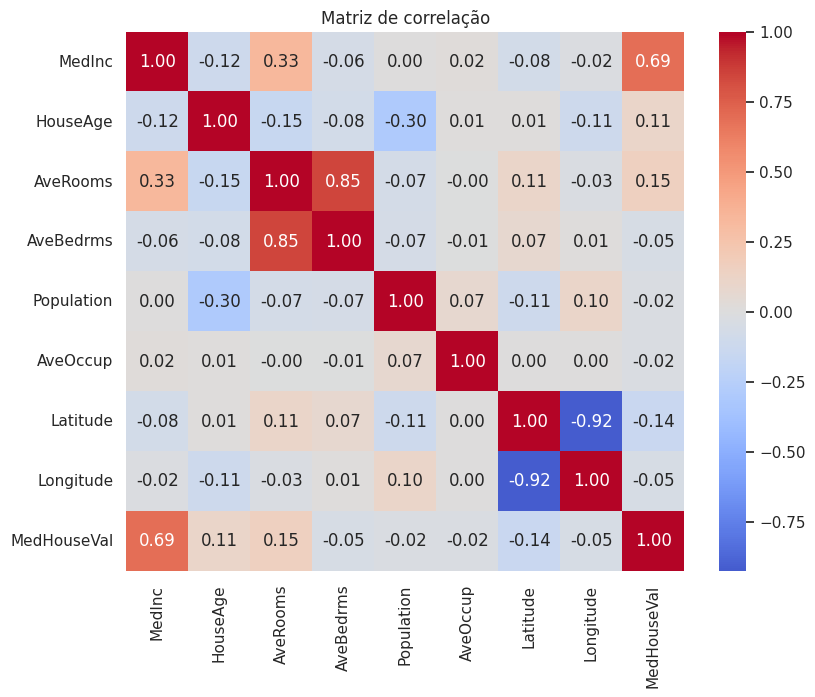

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlação")
plt.show()

A correlação de Pearson mede apenas relações **lineares**. Uma variável com correlação baixa ainda pode ser muito útil se a relação com o alvo for não linear. Latitude e longitude são um bom exemplo: individualmente têm correlação fraca, mas juntas indicam a localização, que influencia muito o preço.

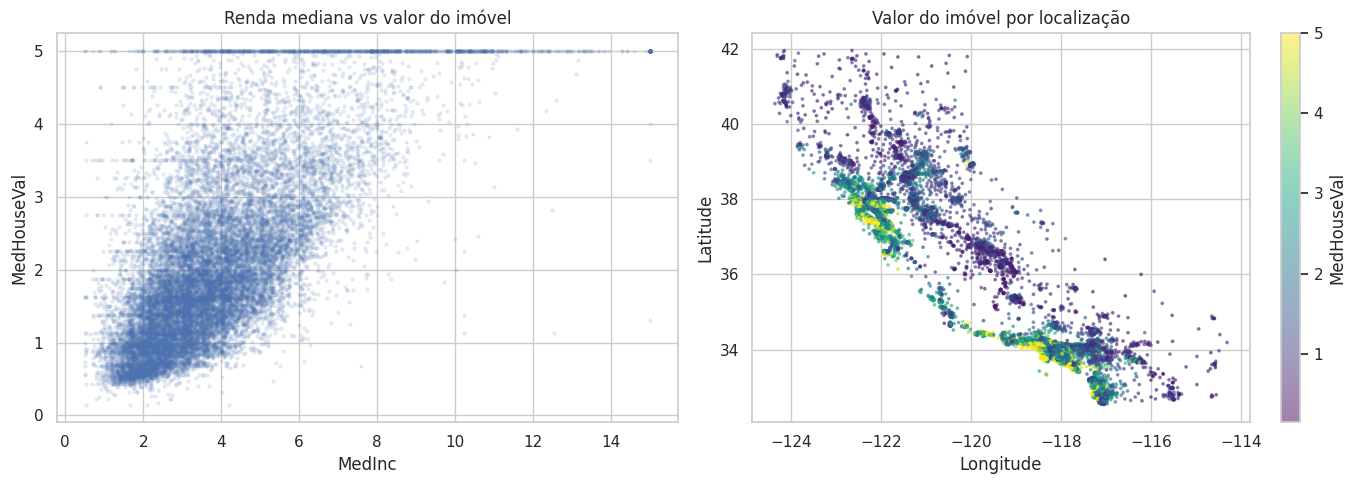

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Renda vs valor do imóvel
axes[0].scatter(df["MedInc"], df["MedHouseVal"], alpha=0.1, s=5)
axes[0].set_xlabel("MedInc")
axes[0].set_ylabel("MedHouseVal")
axes[0].set_title("Renda mediana vs valor do imóvel")

# Localização colorida pelo valor
sc = axes[1].scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"],
                     cmap="viridis", s=3, alpha=0.5)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("Valor do imóvel por localização")
plt.colorbar(sc, ax=axes[1], label="MedHouseVal")

plt.tight_layout()
plt.show()

## 3. Separação entre treino e teste

O modelo aprende com os dados de **treino** e é avaliado nos dados de **teste**, que ele nunca viu. Isso simula o uso real: prever casos novos. Avaliar no próprio treino daria uma visão otimista demais do desempenho.

Uso 80% para treino e 20% para teste.

In [10]:
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} linhas")
print(f"Teste:  {X_test.shape[0]} linhas")

Treino: 16512 linhas
Teste:  4128 linhas


## 4. Métricas de avaliação

| Métrica | O que mede | Interpretação |
|---|---|---|
| **MAE** (erro absoluto médio) | Média do tamanho dos erros | Na mesma unidade do alvo. Quanto menor, melhor. |
| **RMSE** (raiz do erro quadrático médio) | Parecido com o MAE, mas penaliza mais os erros grandes | Na mesma unidade do alvo. Quanto menor, melhor. |
| **R²** (coeficiente de determinação) | Quanto da variação do alvo o modelo explica | 1 é perfeito, 0 equivale a prever sempre a média. |

In [11]:
def avaliar(nome, modelo, X, y):
    """Calcula MAE, RMSE e R² de um modelo já treinado."""
    pred = modelo.predict(X)
    return {
        "Modelo": nome,
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R²": r2_score(y, pred),
    }

resultados = []

## 5. Modelo de referência (baseline)

O baseline prevê **sempre a média** do treino, sem olhar as variáveis. Serve como ponto de comparação: um modelo que não supera o baseline não aprendeu nada útil.

In [12]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

resultados.append(avaliar("Baseline (média)", baseline, X_test, y_test))
pd.DataFrame(resultados).round(3)

,Modelo,MAE,RMSE,R²
0,Baseline (média),0.906,1.145,-0.0


## 6. Regressão Linear

A Regressão Linear assume que o alvo é uma **soma ponderada** das variáveis:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

O modelo encontra os coeficientes $\beta$ que minimizam o erro quadrático no treino.

**Por que padronizar os dados (StandardScaler)?** As variáveis estão em escalas muito diferentes (população na casa dos milhares, renda na casa das unidades). A padronização deixa todas com média 0 e desvio padrão 1. Isso não muda a qualidade das previsões da Regressão Linear, mas torna os coeficientes **comparáveis entre si**.

**Por que usar pipeline?** O `make_pipeline` garante que o scaler aprenda média e desvio **só com os dados de treino**. Se ele visse os dados de teste, haveria vazamento de informação (*data leakage*).

In [13]:
modelo_lr = make_pipeline(StandardScaler(), LinearRegression())
modelo_lr.fit(X_train, y_train)

resultados.append(avaliar("Regressão Linear", modelo_lr, X_test, y_test))
pd.DataFrame(resultados).round(3)

,Modelo,MAE,RMSE,R²
0,Baseline (média),0.906,1.145,-0.000
1,Regressão Linear,0.533,0.746,0.576


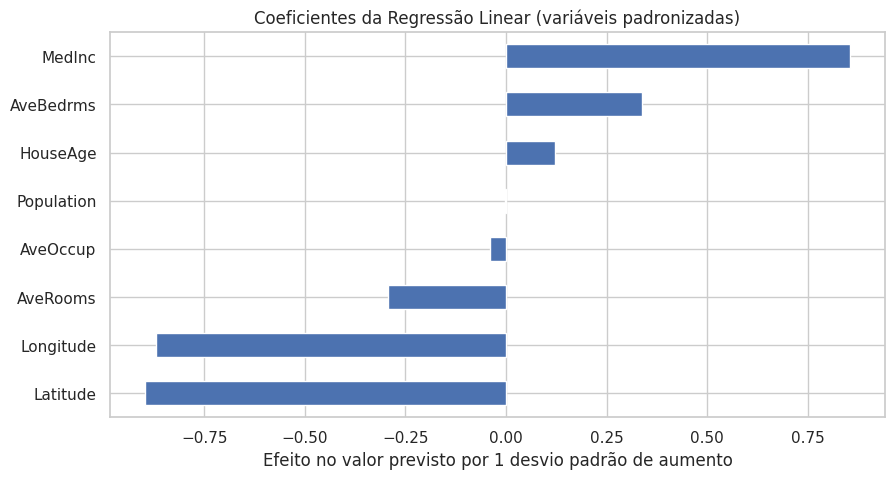

In [14]:
coeficientes = pd.Series(
    modelo_lr.named_steps["linearregression"].coef_,
    index=X.columns
).sort_values()

fig, ax = plt.subplots()
coeficientes.plot(kind="barh", ax=ax)
ax.set_title("Coeficientes da Regressão Linear (variáveis padronizadas)")
ax.set_xlabel("Efeito no valor previsto por 1 desvio padrão de aumento")
plt.show()

**Como ler os coeficientes:** cada barra mostra quanto o valor previsto muda quando a variável aumenta 1 desvio padrão, mantendo as outras fixas. Barras positivas aumentam o preço previsto, negativas diminuem.

**Cuidado:** variáveis correlacionadas entre si (como `AveRooms` e `AveBedrms`) podem ter coeficientes com sinais que parecem contraintuitivos. O modelo divide o efeito entre elas.

## 7. Random Forest Regressor

O Random Forest combina **muitas árvores de decisão**:

1. Cada árvore é treinada com uma amostra aleatória dos dados (com reposição). Essa técnica se chama *bagging*.
2. Em cada divisão da árvore, só um subconjunto aleatório de variáveis é considerado.
3. A previsão final é a **média** das previsões de todas as árvores.

Uma árvore sozinha tende a decorar o treino (*overfitting*). A média de muitas árvores diferentes reduz esse problema.

**Diferença principal em relação à Regressão Linear:** o Random Forest captura **relações não lineares e interações** entre variáveis sem que você precise especificá-las. Por outro lado, é menos interpretável.

**Não precisa de padronização:** árvores dividem os dados por limiares (por exemplo, `MedInc > 5.0`), então a escala das variáveis não afeta o resultado.

**Hiperparâmetros usados:**
- `n_estimators=200`: número de árvores
- `n_jobs=-1`: usa todos os núcleos do processador

In [15]:
modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
modelo_rf.fit(X_train, y_train)

resultados.append(avaliar("Random Forest", modelo_rf, X_test, y_test))
pd.DataFrame(resultados).round(3)

,Modelo,MAE,RMSE,R²
0,Baseline (média),0.906,1.145,-0.000
1,Regressão Linear,0.533,0.746,0.576
2,Random Forest,0.327,0.504,0.806


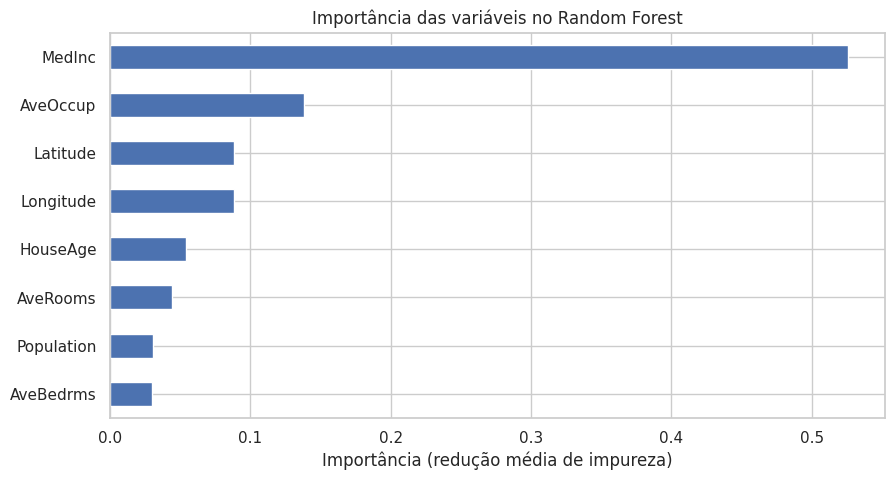

In [16]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values()

fig, ax = plt.subplots()
importancias.plot(kind="barh", ax=ax)
ax.set_title("Importância das variáveis no Random Forest")
ax.set_xlabel("Importância (redução média de impureza)")
plt.show()

**Como ler a importância:** mede o quanto cada variável contribuiu para reduzir o erro nas divisões das árvores. Diferente dos coeficientes lineares, **não indica direção** (se aumenta ou diminui o preço), só relevância.

Compare com o gráfico de coeficientes: as variáveis de localização costumam ganhar peso no Random Forest, porque ele consegue usar latitude e longitude de forma não linear.

### Verificando overfitting

Um sinal de overfitting é o modelo ir muito melhor no treino do que no teste.

In [17]:
for nome, modelo in [("Regressão Linear", modelo_lr), ("Random Forest", modelo_rf)]:
    r2_treino = r2_score(y_train, modelo.predict(X_train))
    r2_teste = r2_score(y_test, modelo.predict(X_test))
    print(f"{nome:18s} | R² treino: {r2_treino:.3f} | R² teste: {r2_teste:.3f} | diferença: {r2_treino - r2_teste:.3f}")

Regressão Linear   | R² treino: 0.613 | R² teste: 0.576 | diferença: 0.037
Random Forest      | R² treino: 0.974 | R² teste: 0.806 | diferença: 0.168


É normal o Random Forest ter R² de treino bem mais alto que o de teste, porque as árvores se ajustam muito aos dados de treino. O que importa é o desempenho no **teste**. Se ele estiver bom, o modelo generaliza bem mesmo com essa diferença. Limitar a profundidade das árvores (`max_depth`) ou o tamanho mínimo das folhas (`min_samples_leaf`) reduziria essa diferença.

## 8. Validação cruzada

Uma única divisão treino/teste pode dar um resultado bom ou ruim por sorte. Na **validação cruzada com 5 folds**, os dados de treino são divididos em 5 partes. O modelo é treinado 5 vezes, cada vez usando uma parte diferente para validação. O resultado final é a média e o desvio padrão das 5 rodadas.

Um desvio padrão baixo indica que o desempenho do modelo é estável.

In [18]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metricas_cv = {"rmse": "neg_root_mean_squared_error", "r2": "r2"}

linhas_cv = []
for nome, modelo in [("Regressão Linear", modelo_lr), ("Random Forest", modelo_rf)]:
    cv = cross_validate(modelo, X_train, y_train, cv=kfold, scoring=metricas_cv, n_jobs=-1)
    linhas_cv.append({
        "Modelo": nome,
        "RMSE médio": -cv["test_rmse"].mean(),
        "RMSE desvio": cv["test_rmse"].std(),
        "R² médio": cv["test_r2"].mean(),
        "R² desvio": cv["test_r2"].std(),
    })

pd.DataFrame(linhas_cv).round(3)

,Modelo,RMSE médio,RMSE desvio,R² médio,R² desvio
0,Regressão Linear,0.721,0.014,0.611,0.012
1,Random Forest,0.510,0.012,0.806,0.006


## 9. Comparação dos modelos

In [19]:
tabela = pd.DataFrame(resultados).set_index("Modelo").round(3)
tabela

,MAE,RMSE,R²
Modelo,,,
Baseline (média),0.906,1.145,-0.000
Regressão Linear,0.533,0.746,0.576
Random Forest,0.327,0.504,0.806


In [20]:
rmse_lr = tabela.loc["Regressão Linear", "RMSE"]
rmse_rf = tabela.loc["Random Forest", "RMSE"]
reducao = (rmse_lr - rmse_rf) / rmse_lr * 100

print(f"O Random Forest reduziu o RMSE em {reducao:.1f}% em relação à Regressão Linear.")

O Random Forest reduziu o RMSE em 32.4% em relação à Regressão Linear.


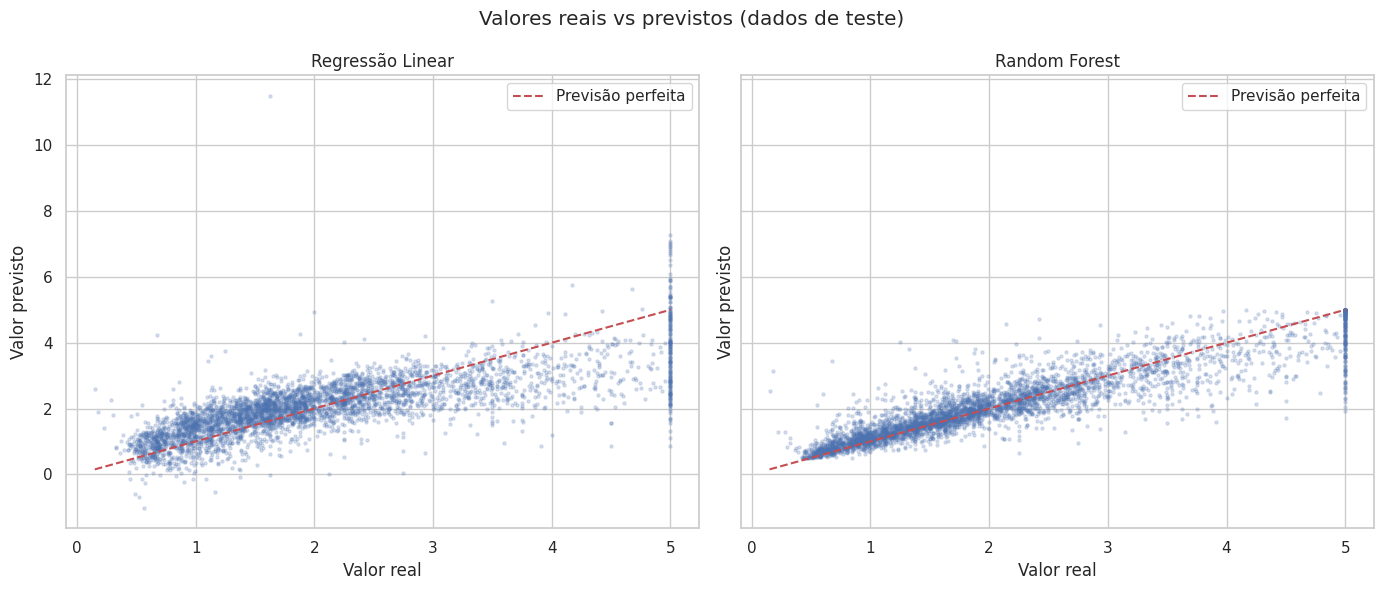

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, (nome, modelo) in zip(axes, [("Regressão Linear", modelo_lr), ("Random Forest", modelo_rf)]):
    pred = modelo.predict(X_test)
    ax.scatter(y_test, pred, alpha=0.2, s=5)
    limites = [y_test.min(), y_test.max()]
    ax.plot(limites, limites, "r--", label="Previsão perfeita")
    ax.set_title(nome)
    ax.set_xlabel("Valor real")
    ax.set_ylabel("Valor previsto")
    ax.legend()

plt.suptitle("Valores reais vs previstos (dados de teste)")
plt.tight_layout()
plt.show()

Quanto mais perto os pontos ficam da linha vermelha, melhor a previsão. Note também como os dois modelos lidam com os imóveis limitados em 5.0.

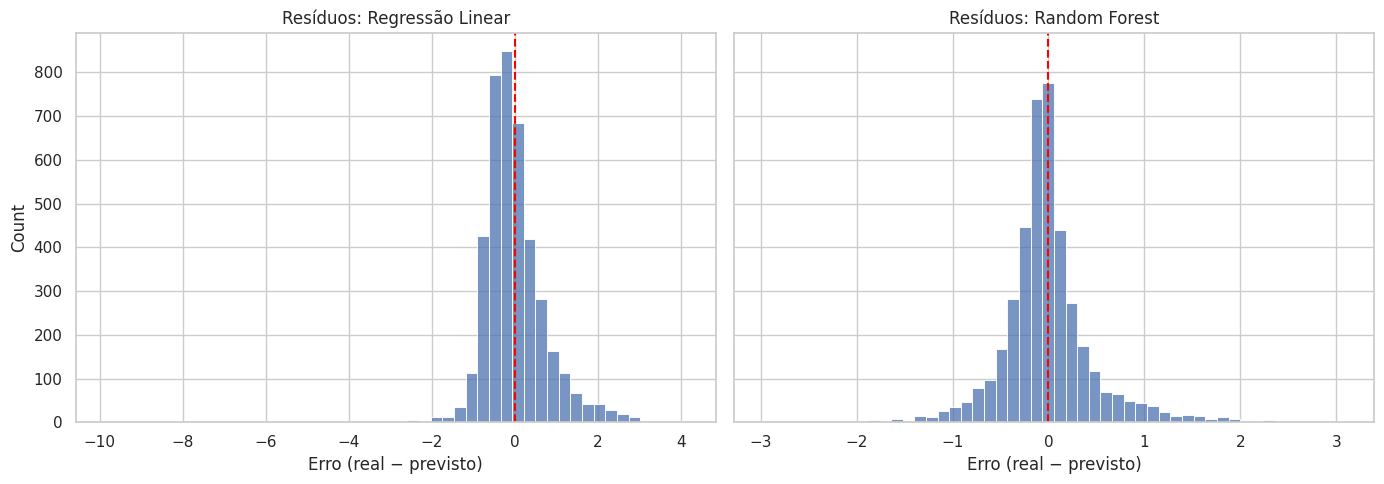

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (nome, modelo) in zip(axes, [("Regressão Linear", modelo_lr), ("Random Forest", modelo_rf)]):
    residuos = y_test - modelo.predict(X_test)
    sns.histplot(residuos, bins=50, ax=ax)
    ax.axvline(0, color="red", linestyle="--")
    ax.set_title(f"Resíduos: {nome}")
    ax.set_xlabel("Erro (real − previsto)")

plt.tight_layout()
plt.show()

**Resíduos** são os erros de cada previsão. O ideal é que fiquem concentrados em torno de zero e simétricos. Uma distribuição mais estreita indica erros menores.

## 10. Conclusões

- **Os dois modelos superam o baseline**, o que confirma que as variáveis têm informação útil para prever o preço.
- **O Random Forest tem desempenho melhor**, porque captura relações não lineares e interações, como o efeito combinado de latitude e longitude.
- **A Regressão Linear continua útil** quando a interpretabilidade importa: os coeficientes mostram a direção e a intensidade do efeito de cada variável.
- **A validação cruzada confirma** se a diferença entre os modelos é consistente ou se foi sorte da divisão treino/teste.

**Trade-off:** desempenho (Random Forest) vs interpretabilidade e simplicidade (Regressão Linear).

## 11. Próximos passos

- Ajustar hiperparâmetros do Random Forest com `GridSearchCV` ou `RandomizedSearchCV`
- Testar modelos de *gradient boosting* (XGBoost, LightGBM)
- Criar novas variáveis (por exemplo, cômodos por pessoa)
- Usar SHAP para interpretar as previsões do Random Forest